In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("C:\\Users\\Asus\\OneDrive\\Desktop\\power shheets\\car.data")
df.head()

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
columns_names=['buying','maint','doors','persons','lug_boot','safety','class']
df.columns=columns_names

In [6]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   object
 3   persons   1727 non-null   object
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [9]:
df.describe(include='all')

,buying,maint,doors,persons,lug_boot,safety,class
count,1727,1727,1727,1727,1727,1727,1727
unique,4,4,4,3,3,3,4
top,high,high,3,4,med,med,unacc
freq,432,432,432,576,576,576,1209


In [11]:
df[df.duplicated()]

,buying,maint,doors,persons,lug_boot,safety,class


In [20]:
from sklearn.preprocessing import OrdinalEncoder
oc=OrdinalEncoder()
df['buying']=oc.fit_transform(df[['buying']])
df['maint']=oc.fit_transform(df[['maint']])
df['doors']=oc.fit_transform(df[['doors']])
df['persons']=oc.fit_transform(df[['persons']])
df['lug_boot']=oc.fit_transform(df[['lug_boot']])
df['safety']=oc.fit_transform(df[['safety']])
df['class']=oc.fit_transform(df[['class']])

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   buying    1727 non-null   float64
 1   maint     1727 non-null   float64
 2   doors     1727 non-null   float64
 3   persons   1727 non-null   float64
 4   lug_boot  1727 non-null   float64
 5   safety    1727 non-null   float64
 6   class     1727 non-null   float64
dtypes: float64(7)
memory usage: 94.6 KB


In [33]:
X=df.drop('class',axis=1)
y=df['class']

In [36]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=20)

In [38]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [41]:
from sklearn.ensemble import RandomForestClassifier
clf=RandomForestClassifier()
clf.fit(X_train,y_train)

RandomForestClassifier()

In [42]:
ypred_train=clf.predict(X_train)
ypred_test=clf.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score
print("accuracy score",accuracy_score(ypred_train,y_train))
from sklearn.model_selection import cross_val_score
print("cross validation score:",cross_val_score(clf,X_train,y_train,cv=5).mean())

accuracy score 1.0
cross validation score: 0.9652383194684246


In [54]:
from sklearn.metrics import accuracy_score
print("accuracy score",accuracy_score(ypred_test,y_test))
from sklearn.model_selection import cross_val_score
print("cross validation score:",cross_val_score(clf,X_test,y_test,cv=5).mean())

accuracy score 0.9826589595375722
cross validation score: 0.8873291925465839


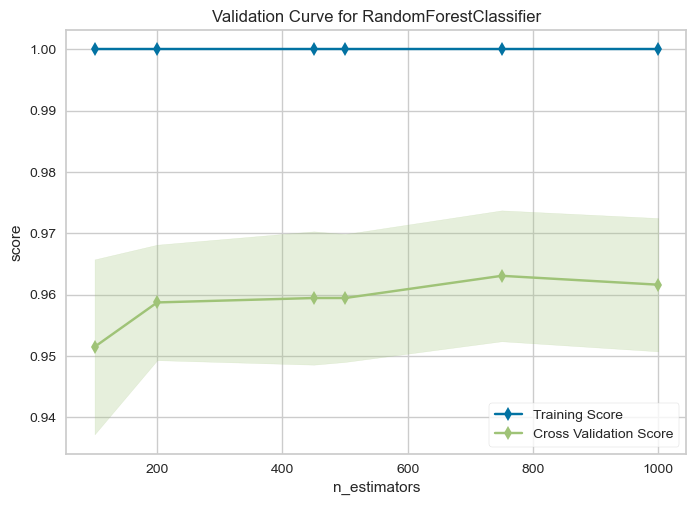

ValidationCurve(ax=<Axes: title={'center': 'Validation Curve for RandomForestClassifier'}, xlabel='n_estimators', ylabel='score'>,
                cv=3, estimator=RandomForestClassifier(),
                param_name='n_estimators',
                param_range=array([ 100,  200,  450,  500,  750, 1000]),
                scoring='accuracy')


In [55]:
from yellowbrick.model_selection import validation_curve
num_est=[100,200,450,500,750,1000]
print(validation_curve(RandomForestClassifier(),X=X_train,y=y_train,param_name='n_estimators',param_range=num_est,scoring='accuracy',cv=3))

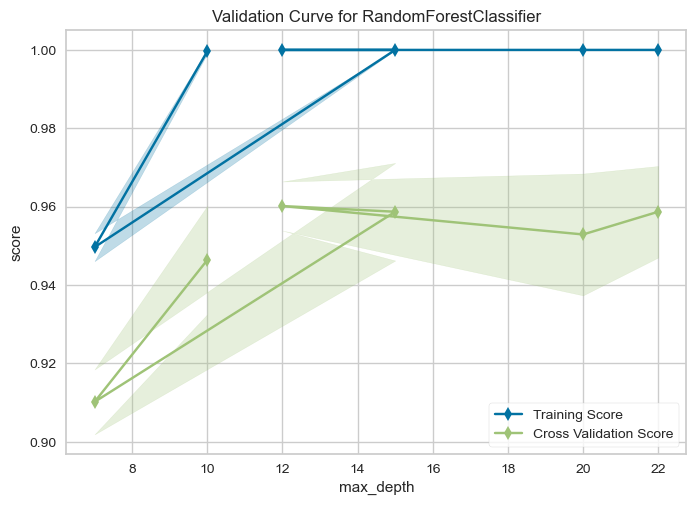

ValidationCurve(ax=<Axes: title={'center': 'Validation Curve for RandomForestClassifier'}, xlabel='max_depth', ylabel='score'>,
                cv=3, estimator=RandomForestClassifier(),
                param_name='max_depth',
                param_range=array([10,  7, 15, 12, 20, 22]),
                scoring='accuracy')


In [56]:
from yellowbrick.model_selection import validation_curve
depth_val=[10,7,15,12,20,22]
print(validation_curve(RandomForestClassifier(),X=X_train,y=y_train,param_name='max_depth',param_range=depth_val,scoring='accuracy',cv=3))

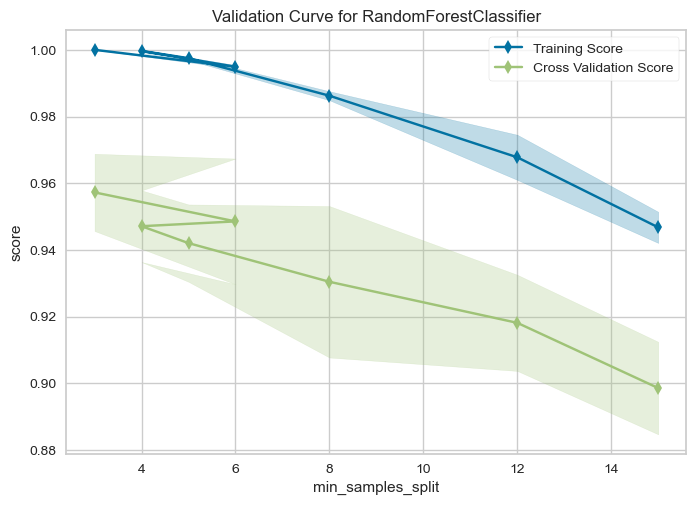

ValidationCurve(ax=<Axes: title={'center': 'Validation Curve for RandomForestClassifier'}, xlabel='min_samples_split', ylabel='score'>,
                cv=3, estimator=RandomForestClassifier(),
                param_name='min_samples_split',
                param_range=array([ 3,  6,  4,  5,  8, 12, 15]),
                scoring='accuracy')


In [57]:
from yellowbrick.model_selection import validation_curve
min_samples=[3,6,4,5,8,12,15]
print(validation_curve(RandomForestClassifier(),X=X_train,y=y_train,param_name='min_samples_split',param_range=min_samples,scoring='accuracy',cv=3))

In [59]:
clf2=RandomForestClassifier(n_estimators=1000,min_samples_split=3,max_depth=15,random_state=0)
clf2.fit(X_train,y_train)

RandomForestClassifier(max_depth=15, min_samples_split=3, n_estimators=1000,
                       random_state=0)

In [60]:
from sklearn.metrics import accuracy_score
print("accuracy score",accuracy_score(ypred_train,y_train))
from sklearn.model_selection import cross_val_score
print("cross validation score:",cross_val_score(clf,X_train,y_train,cv=5).mean())

accuracy score 1.0
cross validation score: 0.9717548265578403


In [70]:
from sklearn.metrics import accuracy_score
print("accuracy score",accuracy_score(ypred_test,y_test))
from sklearn.model_selection import cross_val_score
print("cross validation score:",cross_val_score(clf,X_test,y_test,cv=5).mean())

accuracy score 0.9826589595375722
cross validation score: 0.8845134575569358


In [78]:
f=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']

In [80]:
feature_score=pd.Series(clf2.feature_importances_,index=f).sort_values(ascending=False)
print(feature_score)

safety      0.275879
persons     0.237303
buying      0.189073
maint       0.150227
lug_boot    0.083661
doors       0.063859
dtype: float64


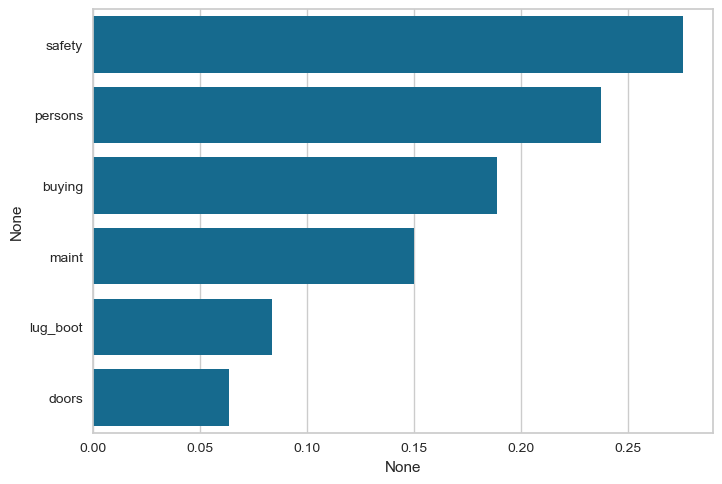

In [82]:
sns.barplot(x=feature_score,y=feature_score.index)
plt.show()

In [85]:
clf3=RandomForestClassifier()
Xn=df.drop(['doors','lug_boot','maint'],axis=1)
yn=df['class']

In [86]:
Xn_train,Xn_test,yn_train,yn_test=train_test_split(Xn,yn,test_size=0.2,random_state=0)

In [87]:
clf3.fit(Xn_train,yn_train)

RandomForestClassifier()

In [88]:
from sklearn.metrics import accuracy_score
print("accuracy score",accuracy_score(ypred_train,y_train))
from sklearn.model_selection import cross_val_score
print("cross validation score:",cross_val_score(clf,X_train,y_train,cv=5).mean())

accuracy score 1.0
cross validation score: 0.9666849788102339


In [89]:
from sklearn.metrics import accuracy_score
print("accuracy score",accuracy_score(ypred_test,y_test))
from sklearn.model_selection import cross_val_score
print("cross validation score:",cross_val_score(clf,X_test,y_test,cv=5).mean())

accuracy score 0.9826589595375722
cross validation score: 0.8873706004140786
